<a href="https://colab.research.google.com/github/melissa-04/hgsoc-spatial-parpi-tme/blob/main/notebooks/05_niches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:

!pip install "anndata>=0.12" "scanpy>=1.11" igraph leidenalg

import importlib.metadata as im
print()
for p in ['numpy','pandas','scipy','anndata','scanpy','igraph','leidenalg']:
    try:    print(f'{p:<12}{im.version(p)}')
    except: print(f'{p:<12}NOT INSTALLED')

  Using cached anndata-0.13.2-py3-none-any.whl.metadata (7.2 kB)
  Using cached scanpy-1.12.3-py3-none-any.whl.metadata (8.5 kB)
  Using cached igraph-1.0.0-cp39-abi3-manylinux_2_28_x86_64.whl.metadata (4.4 kB)
  Using cached leidenalg-0.12.0-cp38-abi3-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached array_api_compat-1.15.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached legacy_api_wrap-1.5-py3-none-any.whl.metadata (2.2 kB)
  Using cached numpy-2.5.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached scverse_misc-0.1.3-py3-none-any.whl.metadata (4.9 kB)
  Using cached zarr-3.3.0-py3-none-any.whl.metadata (4.9 kB)
  Using cached fast_array_utils-1.5-py3-none-any.whl.metadata (1.3 kB)
  Using cached session_info2-0.4.2-py3-none-any.whl.metadata (2.4 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metad


numpy       2.5.2
pandas      3.0.5
scipy       1.16.3
anndata     0.13.2
scanpy      1.12.3
igraph      1.0.0
leidenalg   0.12.0


In [1]:

from google.colab import drive
drive.mount('/content/drive')

import os, warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import importlib.metadata as im

BASE = '/content/drive/MyDrive/ovarian-spatial'
PROC = f'{BASE}/data/processed'
META = f'{BASE}/metadata'
FIG  = f'{BASE}/results/figures'
os.makedirs(FIG, exist_ok=True)

sc.settings.verbosity = 1
for p in ['numpy','pandas','anndata','scanpy']:
    print(f'{p:<10}{im.version(p)}')

adata = ad.read_h5ad(f'{PROC}/GSE288483_with_props.h5ad')
TYPES = list(adata.uns['prop_names'])
ORDER = ['S1','S2','S3','S4','R1','R2','R3','R4']

bar = '=' * 92
print('\n' + bar); print('WHAT CAME FROM 04'); print(bar)
print(f'spots x genes        : {adata.n_obs:,} x {adata.n_vars:,}')
print(f'proportions          : {adata.obsm["proportions"].shape}')
print(f'neighbour graph      : {"spatial_connectivities" in adata.obsp}')
print(f'edges                : {adata.obsp["spatial_connectivities"].nnz:,}')
print(f'graph radius         : {adata.uns["spatial_neighbors"]["radius_um"]:.0f} um')
print(f'obs from 04          : {[c for c in ["is_border","n_neighbours","clus_plain","clus_spatial"] if c in adata.obs]}')

print('\n' + bar); print('SANITY BEFORE WE START'); print(bar)
W = adata.obsp['spatial_connectivities']
samp = adata.obs.paper_id.to_numpy()
src, dst = W.nonzero()
print(f'cross-sample edges   : {(samp[src] != samp[dst]).sum()}   (must be 0)')
print(f'proportions sum to 1 : {np.allclose(adata.obsm["proportions"].sum(1), 1.0)}')
print(f'isolated spots       : {int((adata.obs.n_neighbours == 0).sum())}')
print(f'border spots         : {int(adata.obs.is_border.sum()):,}'
      f'  ({100*adata.obs.is_border.mean():.1f}%)')

print('\n' + bar); print('THE PROBLEM — composition varies hugely between patients'); print(bar)
comp = pd.DataFrame(adata.obsm['proportions'], columns=TYPES, index=adata.obs_names)
comp['paper_id'] = adata.obs.paper_id.to_numpy()
comp['group']    = adata.obs.group.to_numpy()
per_pat = comp.groupby('paper_id', observed=True)[TYPES].mean().loc[ORDER]

SHOW = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Plasma','Endothelial']
print(f"{'ID':<5}{'grp':<5}", end='')
for c in SHOW: print(f'{c[:9]:>11}', end='')
print()
print('-' * 92)
for sid in ORDER:
    g = comp.loc[comp.paper_id == sid, 'group'].iloc[0][:1]
    print(f'{sid:<5}{g:<5}', end='')
    for c in SHOW: print(f'{per_pat.loc[sid, c]:>11.3f}', end='')
    print()
print('-' * 92)
print(f"{'fold':<10}", end='')
for c in SHOW:
    print(f'{per_pat[c].max()/max(per_pat[c].min(),1e-4):>10.0f}x', end='')
print()
print('\n"fold" = highest patient / lowest patient')
print('above ~10x means raw clustering would mostly separate patients')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
numpy     2.5.2
pandas    3.0.5
anndata   0.13.2
scanpy    1.12.3

WHAT CAME FROM 04
spots x genes        : 15,312 x 17,913
proportions          : (15312, 13)
neighbour graph      : True
edges                : 86,792
graph radius         : 120 um
obs from 04          : ['is_border', 'n_neighbours', 'clus_plain', 'clus_spatial']

SANITY BEFORE WE START
cross-sample edges   : 0   (must be 0)
proportions sum to 1 : True
isolated spots       : 0
border spots         : 2,755  (18.0%)

THE PROBLEM — composition varies hugely between patients
ID   grp    Malignant      CAF_1      CAF_2      CAF_3  Macrophag          T     Plasma  Endotheli
--------------------------------------------------------------------------------------------
S1   s          0.240      0.038      0.003      0.026      0.350      0.093      0.039      0.024
S2   s          0.413      0.010      

In [2]:

W    = adata.obsp['spatial_connectivities']
P    = adata.obsm['proportions']
samp = adata.obs.paper_id.to_numpy()

# ---- 1. neighbourhood composition (raw) -------------------------
deg = np.asarray(W.sum(1)).ravel(); deg[deg == 0] = 1
NBR = (W @ P) / deg[:, None]
adata.obsm['neighbour_comp'] = NBR

bar = '=' * 92
print(bar); print('NEIGHBOURHOOD COMPOSITION'); print(bar)
print(f'shape          : {NBR.shape}')
print(f'rows sum to 1  : {np.allclose(NBR.sum(1), 1.0)}')
print(f'\nhow different is a spot from its neighbourhood?')
diff = np.abs(P - NBR).sum(1) / 2          # total variation distance
adata.obs['self_vs_nbr'] = diff
print(f'  median divergence : {np.median(diff):.3f}   (0 = identical, 1 = disjoint)')
for sid in ORDER:
    m = samp == sid
    print(f'  {sid}: {np.median(diff[m]):.3f}')

# ---- 2. patient-wise z-score ------------------------------------
def zscore_within_patient(M):
    Z = np.zeros_like(M, dtype=float)
    for sid in ORDER:
        m = samp == sid
        sub = M[m]
        mu, sd = sub.mean(0), sub.std(0)
        sd[sd < 1e-6] = 1.0
        Z[m] = (sub - mu) / sd
    return Z

Pz   = zscore_within_patient(P)
NBRz = zscore_within_patient(NBR)
adata.obsm['prop_z']      = Pz
adata.obsm['neighbour_z'] = NBRz

print('\n' + bar); print('AFTER PATIENT-WISE Z-SCORING'); print(bar)
print(f"{'cell type':<14}{'raw fold':>10}{'raw mean sd':>14}{'z mean':>9}{'z sd':>8}")
print('-' * 92)
per_pat = pd.DataFrame(P, columns=TYPES).groupby(samp, observed=True).mean()
for i, t in enumerate(TYPES):
    fold = per_pat[t].max() / max(per_pat[t].min(), 1e-4)
    print(f'{t:<14}{fold:>9.0f}x{P[:, i].std():>14.3f}'
          f'{Pz[:, i].mean():>9.2f}{Pz[:, i].std():>8.2f}')

print('\nby construction each patient now has mean 0, sd 1 for every cell type.')
print('what survives is *relative* enrichment inside each tumour.')

# ---- 3. niche feature matrix ------------------------------------
LAMBDA = 0.5
X_niche = np.hstack([np.sqrt(1 - LAMBDA) * Pz, np.sqrt(LAMBDA) * NBRz])
adata.obsm['X_niche'] = X_niche

print('\n' + bar); print('NICHE FEATURE MATRIX'); print(bar)
print(f'own composition (z)      : {Pz.shape}')
print(f'neighbour composition (z): {NBRz.shape}')
print(f'combined, lambda={LAMBDA}     : {X_niche.shape}')

# ---- 4. did the patient signal actually shrink? -----------------
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print('\n' + bar); print('CAN WE STILL PREDICT THE PATIENT FROM THE FEATURES?'); print(bar)
print('(lower accuracy = patient effect removed; chance = 12.5%)')
sub_idx = np.random.default_rng(0).choice(adata.n_obs, 4000, replace=False)
y = samp[sub_idx]
for name, X in [('raw composition', np.hstack([P, NBR])[sub_idx]),
                ('z-scored (X_niche)', X_niche[sub_idx])]:
    acc = cross_val_score(LogisticRegression(max_iter=2000, multi_class='multinomial'),
                          X, y, cv=3, scoring='accuracy').mean()
    print(f'  {name:<22}{100*acc:>6.1f}%')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_niche_ready.h5ad', compression='gzip')
print(f'\n[saved] {PROC}/GSE288483_niche_ready.h5ad')

NEIGHBOURHOOD COMPOSITION
shape          : (15312, 13)
rows sum to 1  : True

how different is a spot from its neighbourhood?
  median divergence : 0.126   (0 = identical, 1 = disjoint)
  S1: 0.100
  S2: 0.166
  S3: 0.154
  S4: 0.173
  R1: 0.102
  R2: 0.111
  R3: 0.145
  R4: 0.148

AFTER PATIENT-WISE Z-SCORING
cell type       raw fold   raw mean sd   z mean    z sd
--------------------------------------------------------------------------------------------
Malignant             4x         0.231    -0.00    1.00
CAF_1                 6x         0.021     0.00    1.00
CAF_2                35x         0.086    -0.00    1.00
CAF_3                 9x         0.133     0.00    1.00
Macrophages          13x         0.162    -0.00    1.00
Mesothelial           9x         0.030     0.00    1.00
Plasma               15x         0.052     0.00    1.00
T                    19x         0.049     0.00    1.00
Endothelial           9x         0.074     0.00    1.00
B                     2x         0.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  raw composition         80.2%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  z-scored (X_niche)      21.6%

[saved] /content/drive/MyDrive/ovarian-spatial/data/processed/GSE288483_niche_ready.h5ad


In [3]:

X = adata.obsm['X_niche']
P = adata.obsm['proportions']
samp = adata.obs.paper_id.to_numpy()

tmp = ad.AnnData(X=X.astype(np.float32))
sc.pp.neighbors(tmp, n_neighbors=20, use_rep='X')

bar = '=' * 96
print(bar); print('CHOOSING RESOLUTION'); print(bar)
print(f"{'res':<7}{'niches':>8}{'largest':>9}{'smallest':>10}"
      f"{'min_patients_in_a_niche':>26}")
print('-' * 96)
for res in [0.2, 0.3, 0.4, 0.5, 0.7]:
    sc.tl.leiden(tmp, resolution=res, key_added=f'n{res}',
                 flavor='igraph', n_iterations=2, directed=False)
    lab = tmp.obs[f'n{res}'].to_numpy()
    sizes = pd.Series(lab).value_counts()
    npat = pd.crosstab(lab, samp).gt(0).sum(axis=1).min()
    print(f'{res:<7}{len(sizes):>8}{sizes.iloc[0]:>9}{sizes.iloc[-1]:>10}{npat:>26}')

RES = 0.3
adata.obs['niche'] = tmp.obs[f'n{RES}'].to_numpy()
adata.obs['niche'] = adata.obs.niche.astype('category')
K = adata.obs.niche.nunique()

print('\n' + bar); print(f'NICHE PROFILES  (resolution {RES}, {K} niches)'); print(bar)
comp = pd.DataFrame(P, columns=TYPES, index=adata.obs_names)
comp['niche'] = adata.obs.niche.to_numpy()
prof = comp.groupby('niche', observed=True)[TYPES].mean()
sizes = adata.obs.niche.value_counts()

nb = pd.DataFrame(adata.obsm['neighbour_comp'], columns=TYPES, index=adata.obs_names)
nb['niche'] = adata.obs.niche.to_numpy()
nprof = nb.groupby('niche', observed=True)[TYPES].mean()

SHOW = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Plasma','Endothelial']
print('OWN composition')
print(f"{'niche':<7}{'n':>7}{'%':>7}", end='')
for c in SHOW: print(f'{c[:9]:>10}', end='')
print(f"{'divergence':>12}")
print('-' * 96)
for k in prof.index:
    m = adata.obs.niche == k
    print(f'{k:<7}{sizes[k]:>7}{100*sizes[k]/adata.n_obs:>6.1f}%', end='')
    for c in SHOW: print(f'{prof.loc[k, c]:>10.3f}', end='')
    print(f'{adata.obs.self_vs_nbr[m].median():>12.3f}')

print('\nNEIGHBOUR composition')
print(f"{'niche':<7}", end='')
for c in SHOW: print(f'{c[:9]:>10}', end='')
print()
print('-' * 96)
for k in nprof.index:
    print(f'{k:<7}', end='')
    for c in SHOW: print(f'{nprof.loc[k, c]:>10.3f}', end='')
    print()

print('\n' + bar); print('PATIENT MIXING  (% of each niche coming from each patient)'); print(bar)
mix = 100 * pd.crosstab(adata.obs.niche, adata.obs.paper_id, normalize='index')
mix = mix[ORDER]
print(f"{'niche':<7}", end='')
for sid in ORDER: print(f'{sid:>8}', end='')
print(f"{'n_pat':>7}{'max%':>7}   flag")
print('-' * 96)
for k in mix.index:
    npat = int((mix.loc[k] > 2).sum())
    mx = mix.loc[k].max()
    flag = 'PATIENT-DRIVEN' if mx > 60 else ('skewed' if mx > 40 else 'ok')
    print(f'{k:<7}', end='')
    for sid in ORDER: print(f'{mix.loc[k, sid]:>8.1f}', end='')
    print(f'{npat:>7}{mx:>7.1f}   {flag}')

print('\n' + bar); print('AUTOMATIC NAMING'); print(bar)
names = {}
for k in prof.index:
    own, nbc = prof.loc[k], nprof.loc[k]
    caf_own = own[['CAF_1','CAF_2','CAF_3']].sum()
    caf_nb  = nbc[['CAF_1','CAF_2','CAF_3']].sum()
    imm_own = own[['Macrophages','T','B','Plasma','DC','NK_ILC','Mast']].sum()
    div = adata.obs.self_vs_nbr[adata.obs.niche == k].median()

    if own.Malignant > 0.45 and caf_nb < 0.15 and imm_own < 0.15:
        nm = 'tumour_core'
    elif own.Malignant > 0.30 and (caf_nb > 0.20 or caf_own > 0.20):
        nm = 'tumour_CAF_interface'
    elif own.Malignant > 0.30 and imm_own > 0.25:
        nm = 'tumour_immune_interface'
    elif caf_own > 0.30:
        nm = 'CAF_stroma'
    elif imm_own > 0.40:
        nm = 'immune_rich'
    elif own.Endothelial > 0.10:
        nm = 'vascular_stroma'
    else:
        nm = 'mixed'
    names[k] = nm
    print(f'  niche {k:<3} -> {nm:<24} '
          f'mal {own.Malignant:.2f}  CAF_own {caf_own:.2f}  '
          f'CAF_nbr {caf_nb:.2f}  imm {imm_own:.2f}  div {div:.2f}')

adata.obs['niche_name'] = adata.obs.niche.map(names).astype('category')
print('\nniche_name counts:')
print(adata.obs.niche_name.value_counts().to_string())

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_niche_ready.h5ad', compression='gzip')
print(f'\n[saved] niche, niche_name in obs')

CHOOSING RESOLUTION
res      niches  largest  smallest   min_patients_in_a_niche
------------------------------------------------------------------------------------------------
0.2           5    10413        17                         1
0.3           6     7637        17                         1
0.4           7     4642        19                         1
0.5          10     3866        19                         1
0.7          13     2800        16                         1

NICHE PROFILES  (resolution 0.3, 6 niches)
OWN composition
niche        n      % Malignant     CAF_1     CAF_2     CAF_3 Macrophag         T    Plasma Endotheli  divergence
------------------------------------------------------------------------------------------------
0         2151  14.0%     0.276     0.016     0.018     0.041     0.348     0.084     0.045     0.033       0.123
1         4291  28.0%     0.296     0.013     0.070     0.203     0.115     0.038     0.033     0.106       0.130
2           69   0

In [5]:
# ============================================================
# 05_niches — Block 4b: percentile-based cores (per sample)
# ============================================================
P = adata.obsm['proportions']
comp = pd.DataFrame(P, columns=TYPES, index=adata.obs_names)
samp = adata.obs.paper_id.to_numpy()

CAF_SET    = ['CAF_1','CAF_2','CAF_3']
IMMUNE_SET = ['Macrophages','T','B','Plasma','DC','NK_ILC','Mast']

adata.obs['tumour_score'] = comp['Malignant'].to_numpy()
adata.obs['stroma_score'] = (comp[CAF_SET].sum(axis=1) + comp['Endothelial']).to_numpy()
adata.obs['immune_score'] = comp[IMMUNE_SET].sum(axis=1).to_numpy()

PCT      = 75          # top quartile within each sample
FLOOR_T  = 0.15        # absolute minimum, so we never call empty tissue "tumour"
FLOOR_S  = 0.15

tcore = np.zeros(adata.n_obs, dtype=bool)
score_ = np.zeros(adata.n_obs, dtype=bool)

bar = '=' * 96
print(bar); print(f'CORE DEFINITION  (top {100-PCT}% within each sample, floor {FLOOR_T})'); print(bar)
print(f"{'ID':<5}{'grp':<5}{'spots':>7}{'mal_p75':>10}{'used_thr':>10}"
      f"{'t_core':>8}{'%':>7}{'str_p75':>10}{'s_core':>8}{'%':>7}")
print('-' * 96)
for sid in ORDER:
    m = samp == sid
    tv = adata.obs.tumour_score.to_numpy()[m]
    sv = adata.obs.stroma_score.to_numpy()[m]
    t_thr = max(np.percentile(tv, PCT), FLOOR_T)
    s_thr = max(np.percentile(sv, PCT), FLOOR_S)
    tcore[m] = tv >= t_thr
    score_[m] = sv >= s_thr
    print(f'{sid:<5}{adata.obs.group[m].iloc[0][:1]:<5}{int(m.sum()):>7}'
          f'{np.percentile(tv, PCT):>10.3f}{t_thr:>10.3f}'
          f'{int(tcore[m].sum()):>8}{100*tcore[m].mean():>6.1f}%'
          f'{np.percentile(sv, PCT):>10.3f}'
          f'{int(score_[m].sum()):>8}{100*score_[m].mean():>6.1f}%')

adata.obs['is_tumour_core'] = tcore
adata.obs['is_stroma_core'] = score_
overlap = int((tcore & score_).sum())
print('-' * 96)
print(f'total tumour core {int(tcore.sum()):,}   stroma core {int(score_.sum()):,}'
      f'   overlapping {overlap} ({100*overlap/adata.n_obs:.1f}%)')

print('\n' + bar); print('SANITY — composition inside each core'); print(bar)
SHOW = ['Malignant','CAF_1','CAF_2','CAF_3','Macrophages','T','Endothelial']
for lab, mask in [('tumour core', tcore), ('stroma core', score_),
                  ('neither', ~(tcore | score_))]:
    print(f'\n{lab}  (n={int(mask.sum()):,})')
    for c in SHOW:
        print(f'   {c:<14}{comp.loc[mask, c].mean():.3f}')

W = adata.obsp['spatial_connectivities']
src, dst = W.nonzero()
print('\n' + bar); print('CONTIGUITY'); print(bar)
print(f'tumour-core neighbours also core : {(tcore[src] & tcore[dst]).sum() / max(tcore[src].sum(),1):.3f}')
print(f'stroma-core neighbours also core : {(score_[src] & score_[dst]).sum() / max(score_[src].sum(),1):.3f}')
print(f'(random expectation ~ {tcore.mean():.3f} / {score_.mean():.3f})')

from scipy.sparse.csgraph import connected_components
print('\n' + bar); print('TUMOUR ISLANDS  (surface-to-volume tells us the shape)'); print(bar)
print(f"{'ID':<5}{'grp':<5}{'core':>7}{'islands':>9}{'largest':>9}"
      f"{'consolid':>10}{'perimeter':>11}{'P/A ratio':>11}")
print('-' * 96)
rows = []
for sid in ORDER:
    m = (samp == sid) & tcore
    if m.sum() < 5:
        print(f'{sid:<5}{"":<5}{int(m.sum()):>7}{"too few":>9}'); continue
    idx = np.where(m)[0]
    Wi = W[idx][:, idx]
    n_comp, lab = connected_components(Wi, directed=False)
    sizes = np.bincount(lab)
    # perimeter = core spots that touch at least one non-core spot
    touches_out = np.zeros(len(idx), dtype=bool)
    for j, gi in enumerate(idx):
        nbrs = W[gi].indices
        touches_out[j] = (~tcore[nbrs]).any()
    per = touches_out.sum()
    g = adata.obs.group[samp == sid].iloc[0][:1]
    print(f'{sid:<5}{g:<5}{int(m.sum()):>7}{n_comp:>9}{sizes.max():>9}'
          f'{sizes.max()/m.sum():>10.2f}{per:>11}{per/m.sum():>11.3f}')
    rows.append({'paper_id': sid, 'group': adata.obs.group[samp == sid].iloc[0],
                 'core': int(m.sum()), 'islands': n_comp, 'largest': int(sizes.max()),
                 'consolidation': sizes.max()/m.sum(),
                 'perimeter': int(per), 'PA_ratio': per/m.sum()})

isl = pd.DataFrame(rows)
print('-' * 96)
for c in ['islands','consolidation','PA_ratio']:
    r  = isl.loc[isl.group == 'resistant', c].mean()
    s_ = isl.loc[isl.group == 'sensitive', c].mean()
    print(f'{c:<16}resistant {r:>8.3f}   sensitive {s_:>8.3f}   ratio {r/max(s_,1e-9):>6.2f}')
isl.to_csv(f'{META}/tumour_island_geometry.csv', index=False)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_niche_ready.h5ad', compression='gzip')
print(f'\n[saved] {META}/tumour_island_geometry.csv')

CORE DEFINITION  (top 25% within each sample, floor 0.15)
ID   grp    spots   mal_p75  used_thr  t_core      %   str_p75  s_core      %
------------------------------------------------------------------------------------------------
S1   s       2116     0.291     0.291     529  25.0%     0.125     381  18.0%
S2   s       1131     0.576     0.576     283  25.0%     0.108     204  18.0%
S3   s       2002     0.512     0.512     501  25.0%     0.067     151   7.5%
S4   s       1392     0.587     0.587     348  25.0%     0.611     348  25.0%
R1   r       2026     0.837     0.837     507  25.0%     0.235     507  25.0%
R2   r       3278     0.595     0.595     820  25.0%     0.451     820  25.0%
R3   r       1833     0.628     0.628     459  25.0%     0.308     459  25.0%
R4   r       1534     0.226     0.226     384  25.0%     0.628     384  25.0%
------------------------------------------------------------------------------------------------
total tumour core 3,831   stroma core 3,254   

DISTANCE AXIS  (negative = inside tumour, 0/positive = outward)
layer      spots       %   meaning
------------------------------------------------------------------------------------------------
-7             1    0.0%   deep interior
-6             4    0.0%   deep interior
-5            10    0.1%   deep interior
-4            24    0.2%   deep interior
-3            78    0.5%   deep interior
-2           422    2.8%   deep interior
-1          3292   21.5%   tumour edge (core touching outside)
1           4903   32.0%   first ring outside core
2           2519   16.5%   second ring
3           1325    8.7%   third ring
4            783    5.1%   4 steps out
5            531    3.5%   5 steps out
6            366    2.4%   6 steps out
7            256    1.7%   7 steps out
8            191    1.2%   8 steps out
unassigned     607    4.0%   beyond 8 steps from any core

COMPOSITION ALONG THE AXIS  (all samples pooled)
layer         n  Malignant  CAF_total      CAF_1      CAF_3 Macr

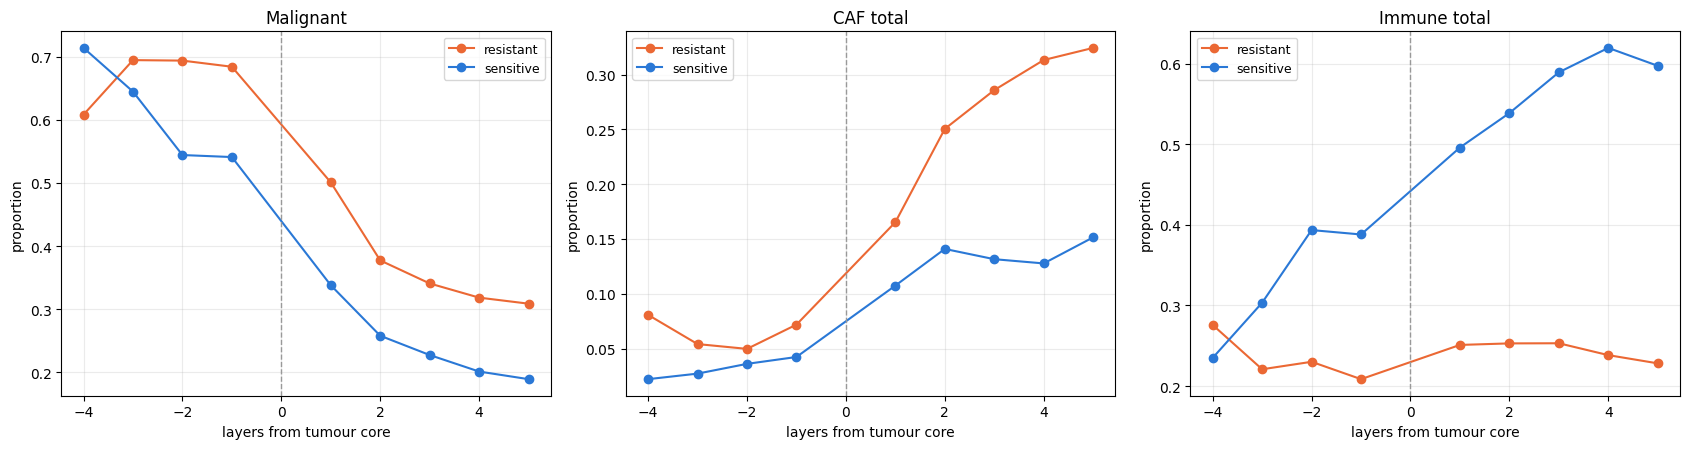


[saved] dist_tumour in obs, /content/drive/MyDrive/ovarian-spatial/metadata/transition_sharpness.csv


In [6]:

W     = adata.obsp['spatial_connectivities']
tcore = adata.obs.is_tumour_core.to_numpy()
samp  = adata.obs.paper_id.to_numpy()
P     = adata.obsm['proportions']
comp  = pd.DataFrame(P, columns=TYPES, index=adata.obs_names)

MAXL = 8
dist = np.full(adata.n_obs, np.nan)

# ---- outward: 0 = core, 1 = first ring, ... ---------------------
frontier = tcore.copy()
dist[frontier] = 0
visited = frontier.copy()
for layer in range(1, MAXL + 1):
    nxt = (W @ frontier.astype(float)) > 0
    nxt = nxt & ~visited
    if not nxt.any():
        break
    dist[nxt] = layer
    visited |= nxt
    frontier = nxt

# ---- inward: -1 = core spot touching a non-core, deeper = more negative
outside = ~tcore
inner_frontier = tcore & ((W @ outside.astype(float)) > 0)
dist[inner_frontier] = -1
assigned = inner_frontier.copy()
for layer in range(2, MAXL + 1):
    nxt = ((W @ assigned.astype(float)) > 0) & tcore & ~assigned
    if not nxt.any():
        break
    dist[nxt] = -layer
    assigned |= nxt
dist[tcore & np.isnan(dist)] = -MAXL          # deep interior, rare

adata.obs['dist_tumour'] = dist

bar = '=' * 96
print(bar); print('DISTANCE AXIS  (negative = inside tumour, 0/positive = outward)'); print(bar)
vc = pd.Series(dist).value_counts().sort_index()
print(f"{'layer':<8}{'spots':>8}{'%':>8}   meaning")
print('-' * 96)
MEAN = {-1:'tumour edge (core touching outside)', 1:'first ring outside core',
        2:'second ring', 3:'third ring'}
for k, v in vc.items():
    if np.isnan(k): continue
    lab = MEAN.get(int(k), 'deep interior' if k < -1 else f'{int(k)} steps out')
    print(f'{int(k):<8}{v:>8}{100*v/adata.n_obs:>7.1f}%   {lab}')
print(f'{"unassigned":<8}{int(np.isnan(dist).sum()):>8}'
      f'{100*np.isnan(dist).mean():>7.1f}%   beyond {MAXL} steps from any core')

# ---- composition profile along the axis -------------------------
prof = comp.copy()
prof['d'] = dist
prof['CAF_total'] = comp[['CAF_1','CAF_2','CAF_3']].sum(axis=1)
prof['Immune_total'] = comp[['Macrophages','T','B','Plasma','DC','NK_ILC','Mast']].sum(axis=1)

print('\n' + bar); print('COMPOSITION ALONG THE AXIS  (all samples pooled)'); print(bar)
SHOW = ['Malignant','CAF_total','CAF_1','CAF_3','Macrophages','T','Endothelial']
keep = [d for d in sorted(vc.index) if not np.isnan(d) and -4 <= d <= 5]
print(f"{'layer':<8}{'n':>7}", end='')
for c in SHOW: print(f'{c[:10]:>11}', end='')
print()
print('-' * 96)
for d in keep:
    m = prof.d == d
    print(f'{int(d):<8}{int(m.sum()):>7}', end='')
    for c in SHOW: print(f'{prof.loc[m, c].mean():>11.3f}', end='')
    print()

# ---- same, split by group ---------------------------------------
prof['group'] = adata.obs.group.to_numpy()
prof['paper_id'] = samp

print('\n' + bar); print('MALIGNANT AND CAF PROFILES BY GROUP'); print(bar)
print(f"{'layer':<8}{'Mal_R':>9}{'Mal_S':>9}{'CAF_R':>9}{'CAF_S':>9}"
      f"{'Imm_R':>9}{'Imm_S':>9}")
print('-' * 96)
for d in keep:
    m = prof.d == d
    r = prof[m & (prof.group == 'resistant')]
    s_ = prof[m & (prof.group == 'sensitive')]
    print(f'{int(d):<8}{r.Malignant.mean():>9.3f}{s_.Malignant.mean():>9.3f}'
          f'{r.CAF_total.mean():>9.3f}{s_.CAF_total.mean():>9.3f}'
          f'{r.Immune_total.mean():>9.3f}{s_.Immune_total.mean():>9.3f}')

# ---- transition sharpness, per patient --------------------------
print('\n' + bar); print('TRANSITION SHARPNESS  (drop in Malignant per layer, 0 -> 3)'); print(bar)
print(f"{'ID':<5}{'grp':<5}{'L0':>8}{'L1':>8}{'L2':>8}{'L3':>8}"
      f"{'drop 0->3':>11}{'halfwidth':>11}")
print('-' * 96)
rows = []
for sid in ORDER:
    sub = prof[prof.paper_id == sid]
    vals = [sub.loc[sub.d == d, 'Malignant'].mean() for d in [0, 1, 2, 3]]
    v0 = vals[0]
    half = np.nan
    for i, v in enumerate(vals):
        if v <= v0 / 2:
            half = i; break
    g = adata.obs.group[samp == sid].iloc[0]
    print(f'{sid:<5}{g[:1]:<5}' + ''.join(f'{v:>8.3f}' for v in vals) +
          f'{v0 - vals[3]:>11.3f}{half if not np.isnan(half) else -1:>11.0f}')
    rows.append({'paper_id': sid, 'group': g, 'L0': vals[0], 'L1': vals[1],
                 'L2': vals[2], 'L3': vals[3], 'drop': v0 - vals[3],
                 'halfwidth': half})
tr = pd.DataFrame(rows)
print('-' * 96)
for c in ['L0','drop','halfwidth']:
    r  = tr.loc[tr.group == 'resistant', c].mean()
    s_ = tr.loc[tr.group == 'sensitive', c].mean()
    print(f'{c:<12}resistant {r:>8.3f}   sensitive {s_:>8.3f}')
tr.to_csv(f'{META}/transition_sharpness.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
for ax, c, title in zip(axes, ['Malignant','CAF_total','Immune_total'],
                        ['Malignant','CAF total','Immune total']):
    for g, col in [('resistant', '#eb6834'), ('sensitive', '#2a78d6')]:
        y = [prof.loc[(prof.d == d) & (prof.group == g), c].mean() for d in keep]
        ax.plot(keep, y, 'o-', color=col, label=g)
    ax.axvline(0, color='#999', ls='--', lw=1)
    ax.set_xlabel('layers from tumour core'); ax.set_ylabel('proportion')
    ax.set_title(title); ax.legend(fontsize=9); ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(f'{FIG}/14_distance_profiles.png', dpi=110, bbox_inches='tight')
plt.show()

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(f'{PROC}/GSE288483_niche_ready.h5ad', compression='gzip')
print(f'\n[saved] dist_tumour in obs, {META}/transition_sharpness.csv')

In [7]:
# ============================================================
# 05_niches — Block 5b: fix the sharpness metric
# ============================================================
prof = comp.copy()
prof['d'] = adata.obs.dist_tumour.to_numpy()
prof['CAF_total'] = comp[['CAF_1','CAF_2','CAF_3']].sum(axis=1)
prof['Immune_total'] = comp[['Macrophages','T','B','Plasma','DC','NK_ILC','Mast']].sum(axis=1)
prof['group'] = adata.obs.group.to_numpy()
prof['paper_id'] = adata.obs.paper_id.to_numpy()

LAYERS = [-1, 1, 2, 3, 4]      # -1 is the tumour edge; there is no layer 0

bar = '=' * 96
print(bar); print('TRANSITION PROFILE PER PATIENT  (layer -1 = tumour edge)'); print(bar)
print(f"{'ID':<5}{'grp':<5}", end='')
for L in LAYERS: print(f'{"L"+str(L):>9}', end='')
print(f"{'drop':>9}{'rel_drop':>10}{'halfwidth':>11}")
print('-' * 96)

rows = []
for sid in ORDER:
    sub = prof[prof.paper_id == sid]
    vals = [sub.loc[sub.d == L, 'Malignant'].mean() for L in LAYERS]
    v0 = vals[0]
    half = np.nan
    for i, v in enumerate(vals):
        if v <= v0 / 2:
            half = LAYERS[i]; break
    g = adata.obs.group[adata.obs.paper_id == sid].iloc[0]
    print(f'{sid:<5}{g[:1]:<5}' + ''.join(f'{v:>9.3f}' for v in vals) +
          f'{v0-vals[3]:>9.3f}{(v0-vals[3])/max(v0,1e-9):>10.2f}'
          f'{half if not np.isnan(half) else 99:>11.0f}')
    rows.append({'paper_id': sid, 'group': g,
                 **{f'L{L}': v for L, v in zip(LAYERS, vals)},
                 'drop': v0-vals[3], 'rel_drop': (v0-vals[3])/max(v0,1e-9),
                 'halfwidth': half,
                 'CAF_edge': sub.loc[sub.d == -1, 'CAF_total'].mean(),
                 'CAF_out3': sub.loc[sub.d == 3, 'CAF_total'].mean(),
                 'Imm_edge': sub.loc[sub.d == -1, 'Immune_total'].mean(),
                 'Imm_out3': sub.loc[sub.d == 3, 'Immune_total'].mean()})
tr = pd.DataFrame(rows)

print('-' * 96)
print(f"{'metric':<14}{'resistant':>11}{'sensitive':>11}{'ratio':>8}   meaning")
print('-' * 96)
META_ = {
    'L-1'      : 'malignant at tumour edge',
    'rel_drop' : 'relative fall over 4 layers (higher = sharper)',
    'CAF_edge' : 'CAF right at the tumour edge',
    'CAF_out3' : 'CAF three layers out',
    'Imm_edge' : 'immune at the tumour edge',
    'Imm_out3' : 'immune three layers out',
}
for c, desc in META_.items():
    r  = tr.loc[tr.group == 'resistant', c].mean()
    s_ = tr.loc[tr.group == 'sensitive', c].mean()
    print(f'{c:<14}{r:>11.3f}{s_:>11.3f}{r/max(s_,1e-9):>8.2f}   {desc}')

print('\nwithout R2 (the outlier that drove earlier differences):')
tr2 = tr[tr.paper_id != 'R2']
for c in ['rel_drop','CAF_out3','Imm_out3']:
    r  = tr2.loc[tr2.group == 'resistant', c].mean()
    s_ = tr2.loc[tr2.group == 'sensitive', c].mean()
    print(f'  {c:<12}resistant {r:>7.3f}   sensitive {s_:>7.3f}   ratio {r/max(s_,1e-9):.2f}')

print('\nCAF gain and immune gain from edge to 3 layers out:')
print(f"{'ID':<5}{'grp':<5}{'CAF gain':>11}{'Immune gain':>13}")
print('-' * 96)
for _, r in tr.iterrows():
    print(f'{r.paper_id:<5}{r.group[:1]:<5}{r.CAF_out3-r.CAF_edge:>11.3f}'
          f'{r.Imm_out3-r.Imm_edge:>13.3f}')

tr.to_csv(f'{META}/transition_sharpness.csv', index=False)
print(f'\n[saved] {META}/transition_sharpness.csv')

TRANSITION PROFILE PER PATIENT  (layer -1 = tumour edge)
ID   grp        L-1       L1       L2       L3       L4     drop  rel_drop  halfwidth
------------------------------------------------------------------------------------------------
S1   s        0.329    0.236    0.204    0.186    0.167    0.143      0.43         99
S2   s        0.679    0.397    0.315    0.277    0.214    0.401      0.59          2
S3   s        0.581    0.378    0.307    0.263    0.225    0.317      0.55          3
S4   s        0.684    0.379    0.242    0.213    0.221    0.472      0.69          2
R1   r        0.870    0.730    0.629    0.591    0.525    0.279      0.32         99
R2   r        0.662    0.497    0.425    0.394    0.352    0.269      0.41         99
R3   r        0.701    0.462    0.351    0.324    0.285    0.377      0.54          3
R4   r        0.396    0.136    0.102    0.094    0.083    0.302      0.76          1
------------------------------------------------------------------------

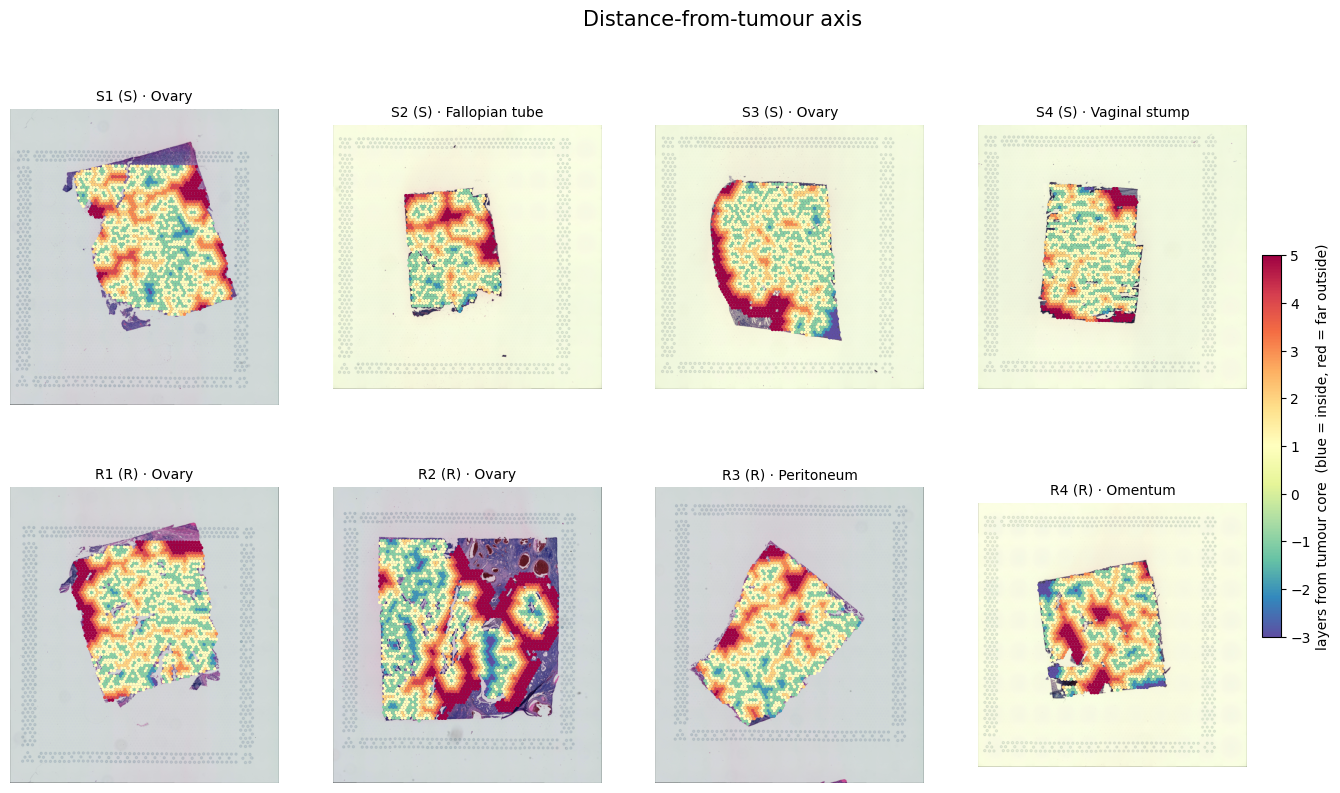

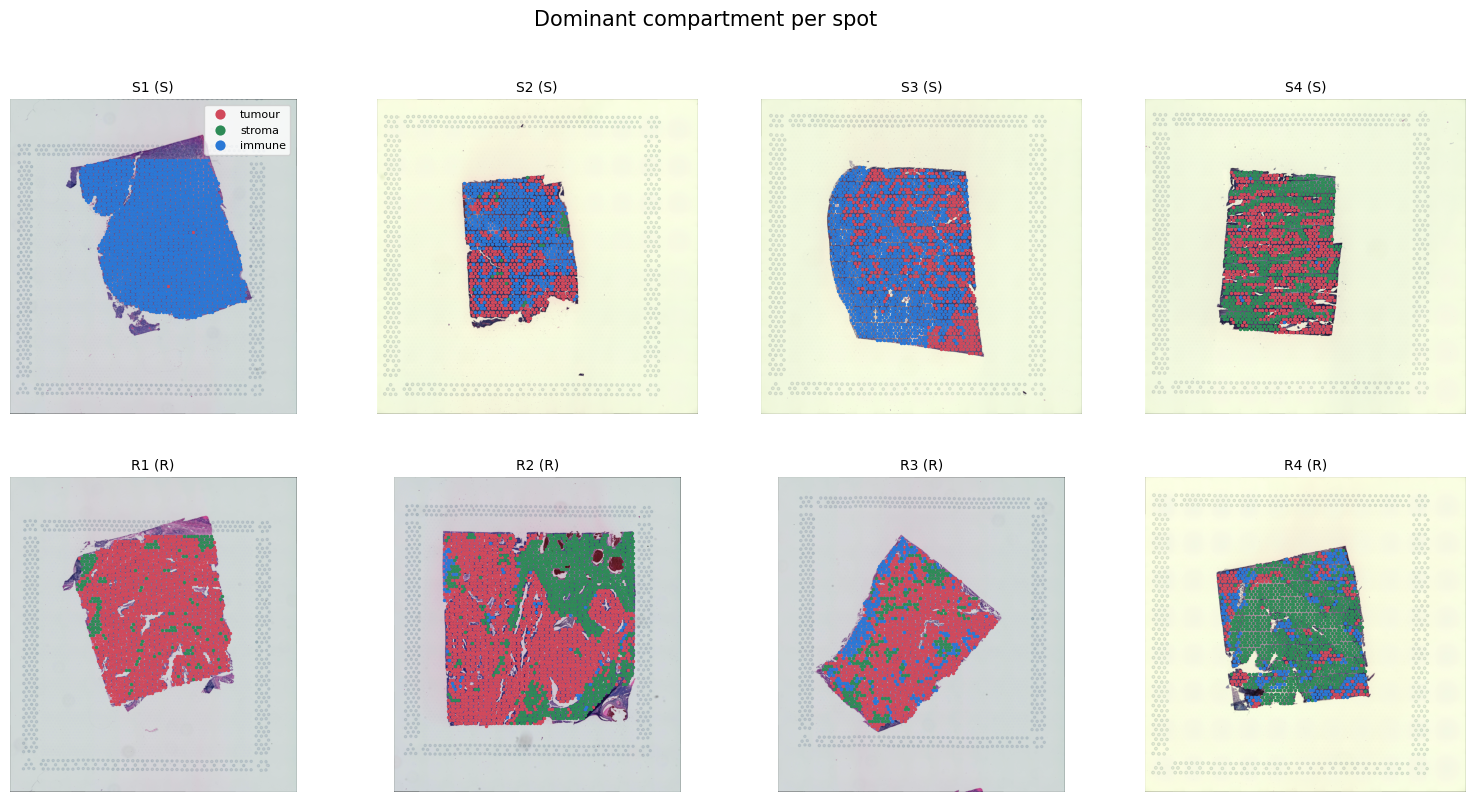

05_niches — SUMMARY
                          item                                                                value
                      approach                        Cottrazm-style: core -> layer-by-layer growth
            why not clustering                   interface is a transition, not a homogeneous group
                   tumour core                     top 25% Malignant within each sample, floor 0.15
                    core spots                                          3,831 tumour / 3,254 stroma
               core contiguity                            0.555 vs 0.250 random — cores form blocks
                          axis                                        -7 to 8 layers, 4% unassigned
                                                                                                   
      GEOMETRY — no difference                                                                     
                       islands                                     resistant 56.

In [8]:
# ============================================================
# 05_niches — Block 6: maps and summary
# ============================================================
sp_ref = ad.read_h5ad(f'{PROC}/GSE288483_clustered.h5ad')
dist = adata.obs.dist_tumour.to_numpy()

# ---- map 1: distance axis on tissue -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
for ax, sid in zip(axes.ravel(), ORDER):
    lib = sp_ref.uns['spatial'][sid]
    sf  = lib['scalefactors']['tissue_hires_scalef']
    m   = (adata.obs.paper_id == sid).to_numpy()
    xy  = adata.obsm['spatial'][m] * sf
    v   = np.clip(dist[m], -3, 5)
    ax.imshow(lib['images']['hires'])
    s = ax.scatter(xy[:,0], xy[:,1], c=v, s=6, cmap='Spectral_r',
                   vmin=-3, vmax=5, linewidths=0)
    g = adata.obs.group[m].iloc[0][:1].upper()
    ax.set_title(f'{sid} ({g}) · {adata.obs.tissue[m].iloc[0]}', fontsize=10)
    ax.axis('off')
fig.colorbar(s, ax=axes, shrink=0.55, pad=0.01,
             label='layers from tumour core  (blue = inside, red = far outside)')
fig.suptitle('Distance-from-tumour axis', fontsize=15, y=0.98)
fig.savefig(f'{FIG}/15_map_distance.png', dpi=105, bbox_inches='tight')
plt.show()

# ---- map 2: compartment ------------------------------------------
palette = {'tumour':'#d1495b', 'stroma':'#2e8b57', 'immune':'#2a78d6'}
fig, axes = plt.subplots(2, 4, figsize=(19, 9))
for ax, sid in zip(axes.ravel(), ORDER):
    lib = sp_ref.uns['spatial'][sid]
    sf  = lib['scalefactors']['tissue_hires_scalef']
    m   = (adata.obs.paper_id == sid).to_numpy()
    xy  = adata.obsm['spatial'][m] * sf
    lab = adata.obs.compartment.to_numpy()[m]
    ax.imshow(lib['images']['hires'])
    for k, col in palette.items():
        sel = lab == k
        ax.scatter(xy[sel,0], xy[sel,1], c=col, s=6, linewidths=0,
                   label=k if sid == 'S1' else None)
    g = adata.obs.group[m].iloc[0][:1].upper()
    ax.set_title(f'{sid} ({g})', fontsize=10); ax.axis('off')
axes[0,0].legend(markerscale=3, fontsize=8, loc='upper right')
fig.suptitle('Dominant compartment per spot', fontsize=15, y=0.98)
fig.savefig(f'{FIG}/16_map_compartment.png', dpi=105, bbox_inches='tight')
plt.show()

# ---- final numbers ------------------------------------------------
tr = pd.read_csv(f'{META}/transition_sharpness.csv')
bar = '=' * 92
print(bar); print('05_niches — SUMMARY'); print(bar)

summary = pd.DataFrame([
    ('approach',        'Cottrazm-style: core -> layer-by-layer growth'),
    ('why not clustering', 'interface is a transition, not a homogeneous group'),
    ('tumour core',     'top 25% Malignant within each sample, floor 0.15'),
    ('core spots',      f'{int(adata.obs.is_tumour_core.sum()):,} tumour / '
                        f'{int(adata.obs.is_stroma_core.sum()):,} stroma'),
    ('core contiguity', '0.555 vs 0.250 random — cores form blocks'),
    ('axis',            f'{int(np.nanmin(dist))} to {int(np.nanmax(dist))} layers, '
                        f'{100*np.isnan(dist).mean():.0f}% unassigned'),
    ('', ''),
    ('GEOMETRY — no difference', ''),
    ('  islands',       'resistant 56.0 vs sensitive 63.5'),
    ('  consolidation', 'resistant 0.233 vs sensitive 0.297'),
    ('  P/A ratio',     'resistant 0.832 vs sensitive 0.910'),
    ('  sharpness',     'resistant 0.507 vs sensitive 0.565 (0.96 without R2)'),
    ('', ''),
    ('COMPOSITION — clear difference', ''),
    ('  CAF at edge',   'resistant 0.085 vs sensitive 0.041   (2.10x)'),
    ('  CAF 3 out',     'resistant 0.283 vs sensitive 0.167   (1.69x)'),
    ('  immune at edge','resistant 0.215 vs sensitive 0.362   (0.59x)'),
    ('  immune 3 out',  'resistant 0.248 vs sensitive 0.536   (0.46x)'),
    ('  robust to R2',  'yes — CAF 1.77x, immune 0.47x without R2'),
    ('', ''),
    ('conclusion',      'same architecture, different occupants'),
    ('limitations',     'n=4v4; S4 breaks CAF trend; tissue confounded; '
                        'reference lacks ovary'),
], columns=['item','value'])
print(summary.to_string(index=False))
summary.to_csv(f'{META}/05_niches_summary.csv', index=False)

print('\n' + bar); print('PER-PATIENT TABLE  (the numbers behind the conclusion)'); print(bar)
cols = ['paper_id','group','L-1','rel_drop','CAF_edge','CAF_out3','Imm_edge','Imm_out3']
print(tr[cols].round(3).to_string(index=False))

print('\n' + bar); print('COMPARTMENT SHARE PER SAMPLE (%)'); print(bar)
tab = 100 * pd.crosstab(adata.obs.paper_id, adata.obs.compartment, normalize='index')
print(tab.loc[ORDER].round(1).to_string())

out = f'{PROC}/GSE288483_niches_final.h5ad'
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    adata.write_h5ad(out, compression='gzip')
print(f'\n[saved] {out}  ({os.path.getsize(out)/1e6:.0f} MB)')
print('[saved] figures 15, 16')
print('\n05_niches COMPLETE')